## 1. Необходимые библиотеки:

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

## 2. Загрузка и первичный анализ данных

In [8]:
file_path = 'marketing_campaign.csv'
df = pd.read_csv(file_path, sep='\t')
print(df)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.dropna())

         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012       58       635  ...            

## 3. Визуализация данных

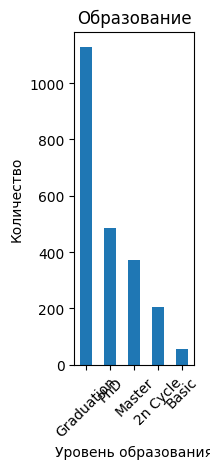

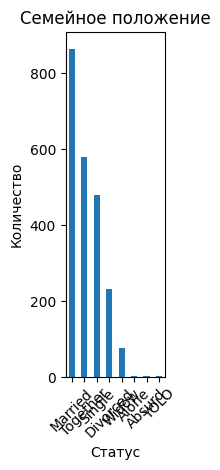

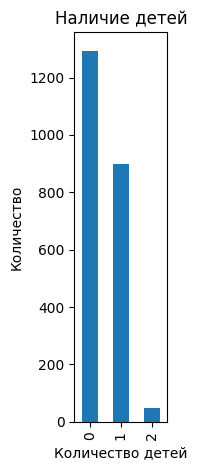

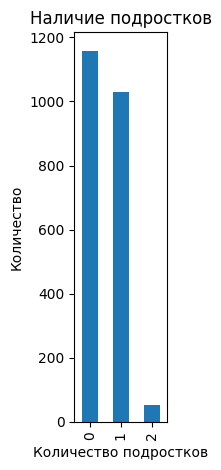

In [16]:
plt.subplot(1, 4, 1)
df['Education'].value_counts().plot(kind='bar')
plt.title('Образование')
plt.xlabel('Уровень образования')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.subplot(1, 4, 2)
df['Marital_Status'].value_counts().plot(kind='bar')
plt.title('Семейное положение')
plt.xlabel('Статус')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.subplot(1, 4, 3)
df['Kidhome'].value_counts().sort_index().plot(kind='bar')
plt.title('Наличие детей')
plt.xlabel('Количество детей')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()


plt.subplot(1, 4, 4)
df['Teenhome'].value_counts().sort_index().plot(kind='bar')
plt.title('Наличие подростков')
plt.xlabel('Количество подростков')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

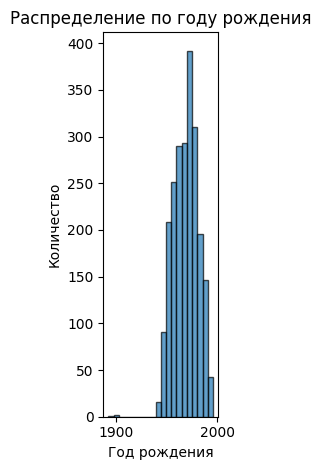

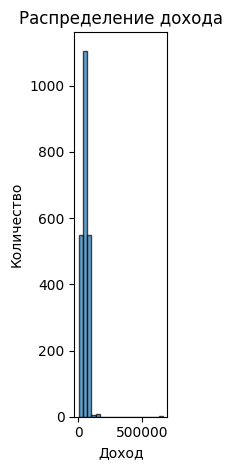

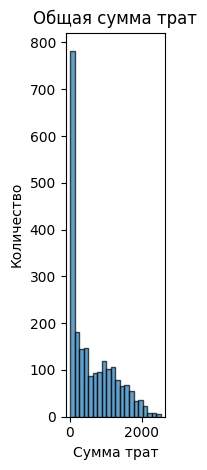

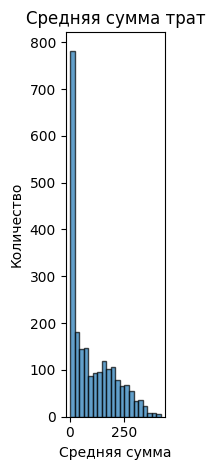

In [18]:
plt.subplot(1, 4, 1)
plt.hist(df['Year_Birth'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение по году рождения')
plt.xlabel('Год рождения')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()


plt.subplot(1, 4, 2)
plt.hist(df['Income'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение дохода')
plt.xlabel('Доход')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()


total_spent = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
plt.subplot(1, 4, 3)
plt.hist(total_spent, bins=20, edgecolor='black', alpha=0.7)
plt.title('Общая сумма трат')
plt.xlabel('Сумма трат')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()


avg_spent = total_spent / 6
plt.subplot(1, 4, 4)
plt.hist(avg_spent, bins=20, edgecolor='black', alpha=0.7)
plt.title('Средняя сумма трат')
plt.xlabel('Средняя сумма')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

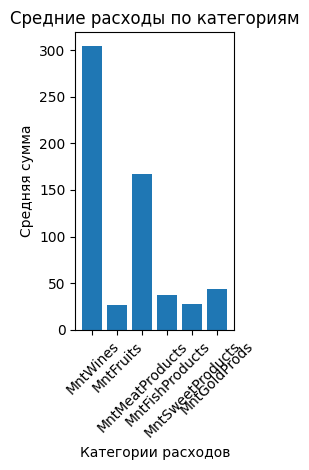

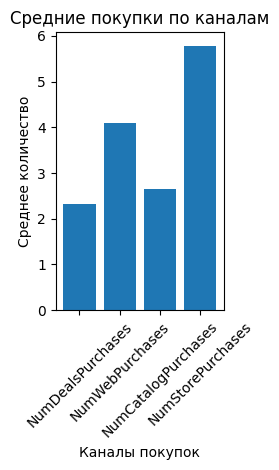

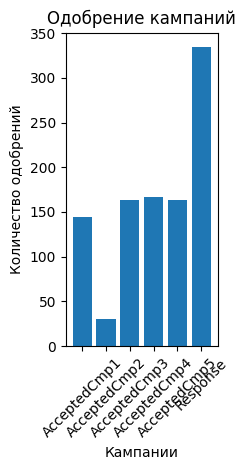

In [20]:
plt.subplot(1, 3, 1)
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spending_means = df[spending_cols].mean()
plt.bar(range(len(spending_cols)), spending_means)
plt.title('Средние расходы по категориям')
plt.xlabel('Категории расходов')
plt.ylabel('Средняя сумма')
plt.xticks(range(len(spending_cols)), spending_cols, rotation=45)
plt.tight_layout()
plt.show()


plt.subplot(1, 3, 2)
purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
purchase_means = df[purchase_cols].mean()
plt.bar(range(len(purchase_cols)), purchase_means)
plt.title('Средние покупки по каналам')
plt.xlabel('Каналы покупок')
plt.ylabel('Среднее количество')
plt.xticks(range(len(purchase_cols)), purchase_cols, rotation=45)
plt.tight_layout()
plt.show()


plt.subplot(1, 3, 3)
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_sums = df[campaign_cols].sum()
plt.bar(range(len(campaign_cols)), campaign_sums)
plt.title('Одобрение кампаний')
plt.xlabel('Кампании')
plt.ylabel('Количество одобрений')
plt.xticks(range(len(campaign_cols)), campaign_cols, rotation=45)

plt.tight_layout()
plt.show()

## 4. Предобработка данных

In [22]:
print(df.describe().T)

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
print(f"\nСамая ранняя дата присоединения: {df['Dt_Customer'].min()}")
print(f"Самая поздняя дата присоединения: {df['Dt_Customer'].max()}")

df['Age'] = 2021 - df['Year_Birth']
df['Total_spent'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df['Partner'] = df['Marital_Status'].apply(lambda x: 1 if x in ['Married', 'Together'] else 0)
df['Children'] = df['Kidhome'] + df['Teenhome']
df['Family_size'] = df['Children'] + df['Partner'] + 1  # +1 для самого клиента
df['Customer_For'] = (pd.to_datetime('2021-12-31') - df['Dt_Customer']).dt.days

df_clean = df.drop(['Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'ID'], axis=1)

print(df_clean.info())

                      count                           mean  \
ID                   2240.0                    5592.159821   
Year_Birth           2240.0                    1968.805804   
Income               2216.0                   52247.251354   
Kidhome              2240.0                       0.444196   
Teenhome             2240.0                        0.50625   
Dt_Customer            2240  2013-07-10 10:01:42.857142784   
Recency              2240.0                      49.109375   
MntWines             2240.0                     303.935714   
MntFruits            2240.0                      26.302232   
MntMeatProducts      2240.0                         166.95   
MntFishProducts      2240.0                      37.525446   
MntSweetProducts     2240.0                      27.062946   
MntGoldProds         2240.0                      44.021875   
NumDealsPurchases    2240.0                          2.325   
NumWebPurchases      2240.0                       4.084821   
NumCatal

## 5. Исследование данных и кодирование

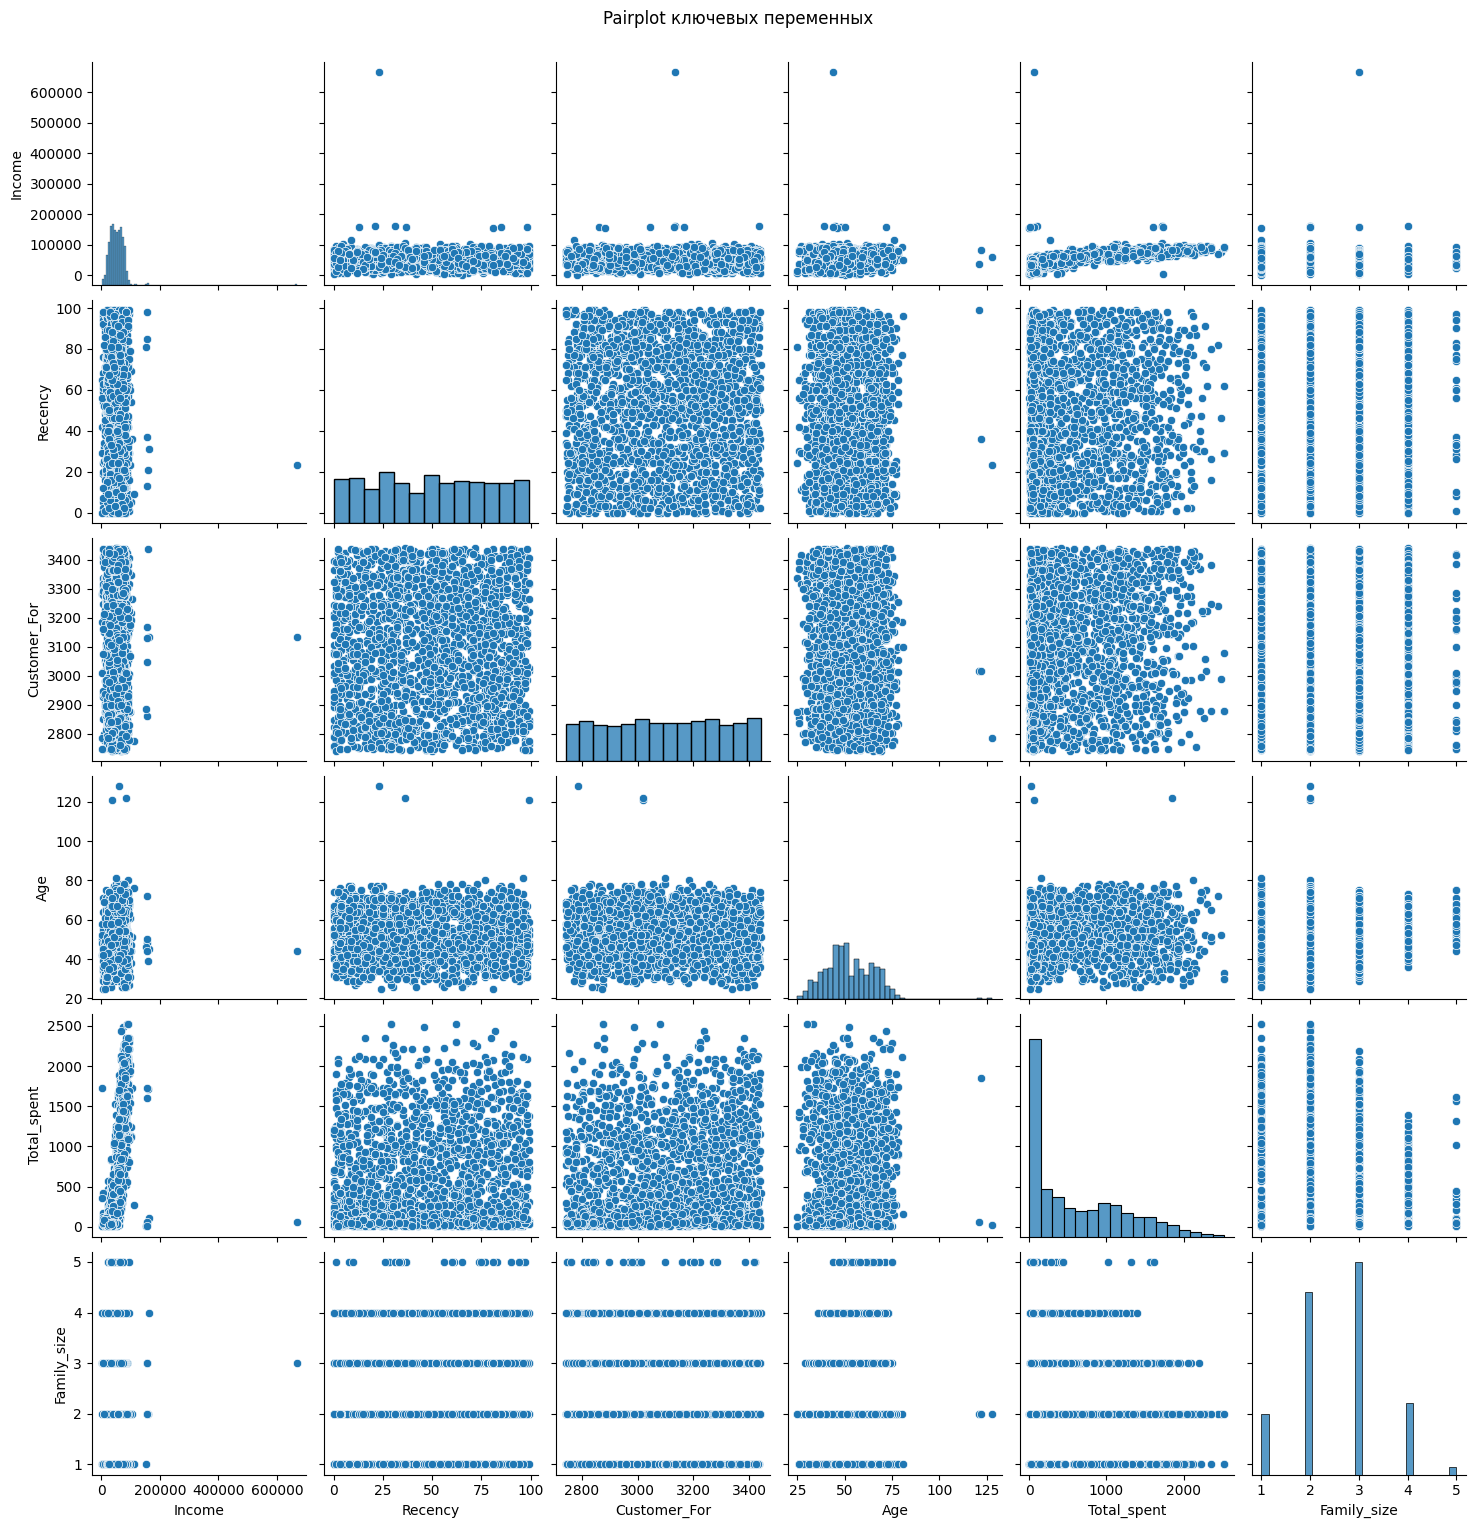


Статистика после обработки:
                         count          mean           std     min      25%  \
Income                  2205.0  51622.094785  20713.063826  1730.0  35196.0   
Kidhome                 2205.0      0.442177      0.537132     0.0      0.0   
Teenhome                2205.0      0.506576      0.544380     0.0      0.0   
Recency                 2205.0     49.009070     28.932111     0.0     24.0   
MntWines                2205.0    306.164626    337.493839     0.0     24.0   
MntFruits               2205.0     26.403175     39.784484     0.0      2.0   
MntMeatProducts         2205.0    165.312018    217.784507     0.0     16.0   
MntFishProducts         2205.0     37.756463     54.824635     0.0      3.0   
MntSweetProducts        2205.0     27.128345     41.130468     0.0      1.0   
MntGoldProds            2205.0     44.057143     51.736211     0.0      9.0   
NumDealsPurchases       2205.0      2.318367      1.886107     0.0      1.0   
NumWebPurchases        

In [23]:
key_cols = ['Income', 'Recency', 'Customer_For', 'Age', 'Total_spent', 'Family_size']
sns.pairplot(df_clean[key_cols].dropna())
plt.suptitle('Pairplot ключевых переменных', y=1.02)
plt.show()

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_clean = remove_outliers(df_clean, 'Age')
df_clean = remove_outliers(df_clean, 'Income')

le_education = LabelEncoder()
le_marital = LabelEncoder()

df_clean['Education_encoded'] = le_education.fit_transform(df_clean['Education'])
df_clean['Marital_Status_encoded'] = le_marital.fit_transform(df_clean['Marital_Status'])

print("\nСтатистика после обработки:")
print(df_clean.describe().T)


## 6. Корреляционный анализ и масштабирование признаков

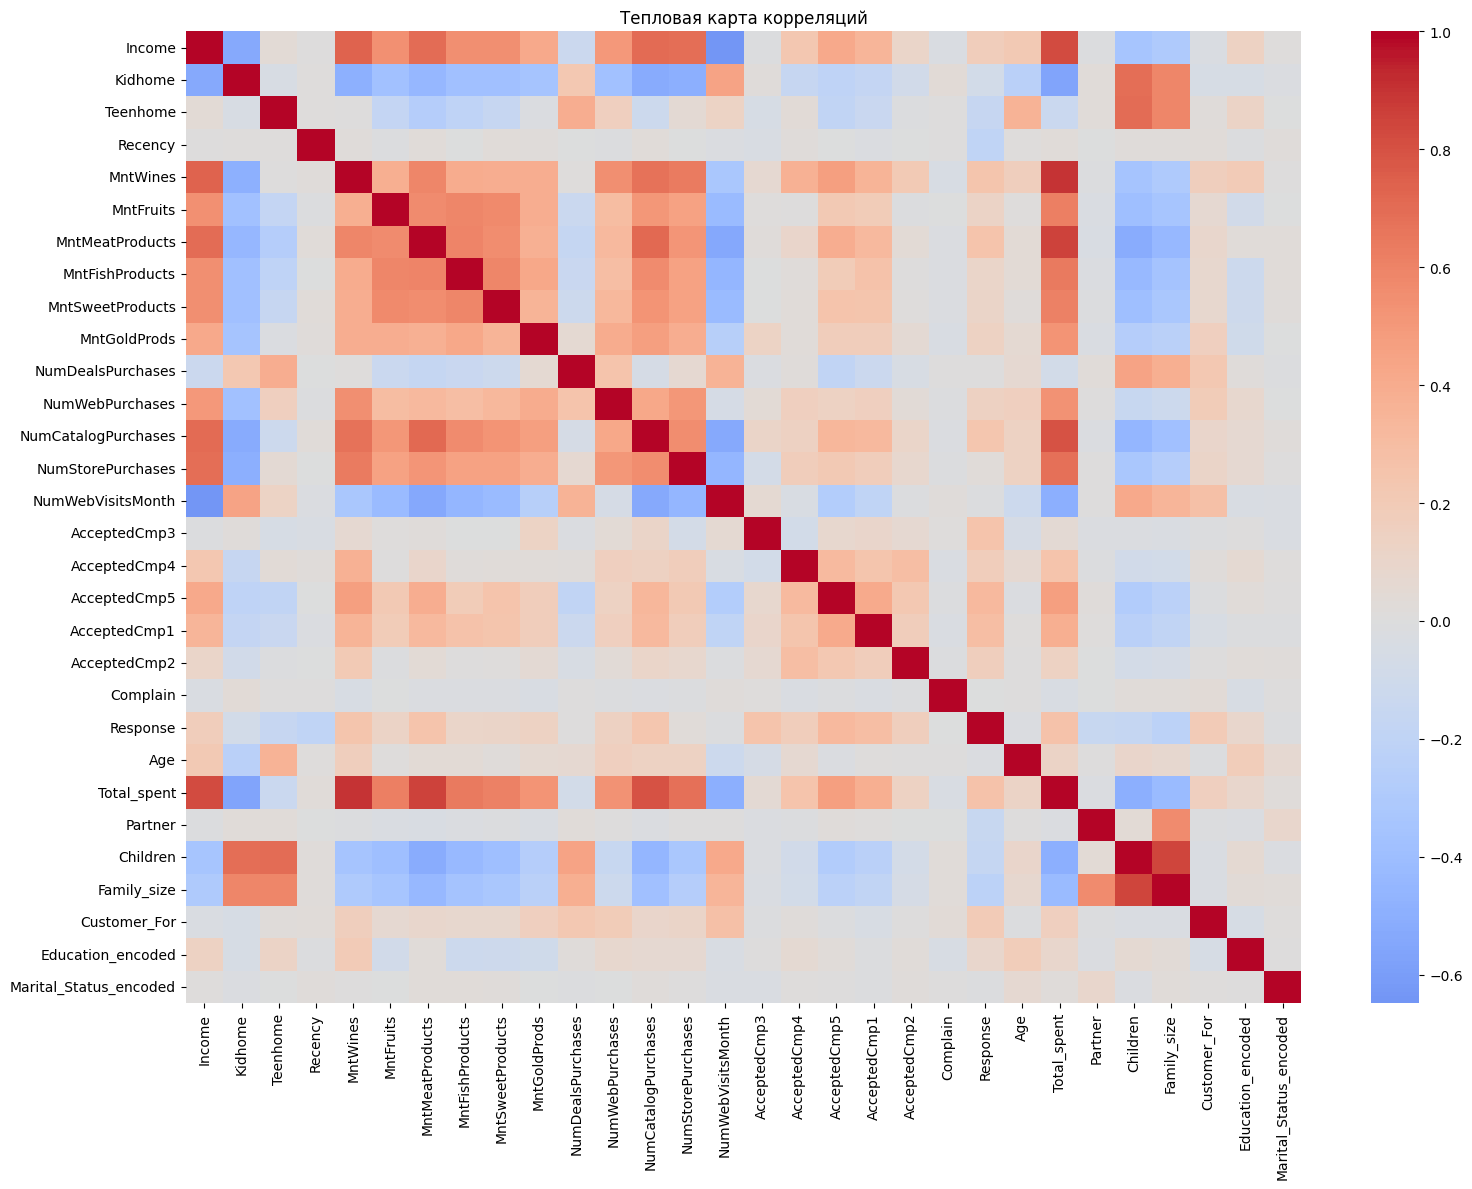

Размер масштабированного датасета: (2205, 21)
Первые 5 строк масштабированного датасета:
     Income   Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  0.314651  0.310830  0.974566   1.548614         1.748400         2.449154   
1 -0.254877 -0.380600 -0.874776  -0.638664        -0.731678        -0.652345   
2  0.965354 -0.795458  0.355155   0.568110        -0.175957         1.336263   
3 -1.206087 -0.795458 -0.874776  -0.563241        -0.667380        -0.506392   
4  0.322136  1.555404 -0.394659   0.417263        -0.217292         0.150396   

   MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  ...  \
0          1.480301      0.849556           0.361479         1.424772  ...   
1         -0.635399     -0.735767          -0.168834        -1.132957  ...   
2         -0.149031     -0.039771          -0.699147         1.424772  ...   
3         -0.586763     -0.755100          -0.168834        -0.767567  ...   
4         -0.003121     -0.561768       

In [24]:
plt.figure(figsize=(16, 12))
correlation_matrix = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()


df2 = df_clean.copy()
target_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Response']
df2 = df2.drop(target_cols, axis=1)


numeric_cols = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 
                'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 
                'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Total_spent', 
                'Children', 'Family_size', 'Customer_For']

categorical_cols = ['Education_encoded', 'Marital_Status_encoded', 'Partner']

scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(df2[numeric_cols])
scaled_numeric_df = pd.DataFrame(scaled_numeric, columns=numeric_cols, index=df2.index)

scaled_df = pd.concat([scaled_numeric_df, df2[categorical_cols]], axis=1)

print(f"Размер масштабированного датасета: {scaled_df.shape}")
print("Первые 5 строк масштабированного датасета:")
print(scaled_df.head())

## 7. Понижение размерности с помощью PCA

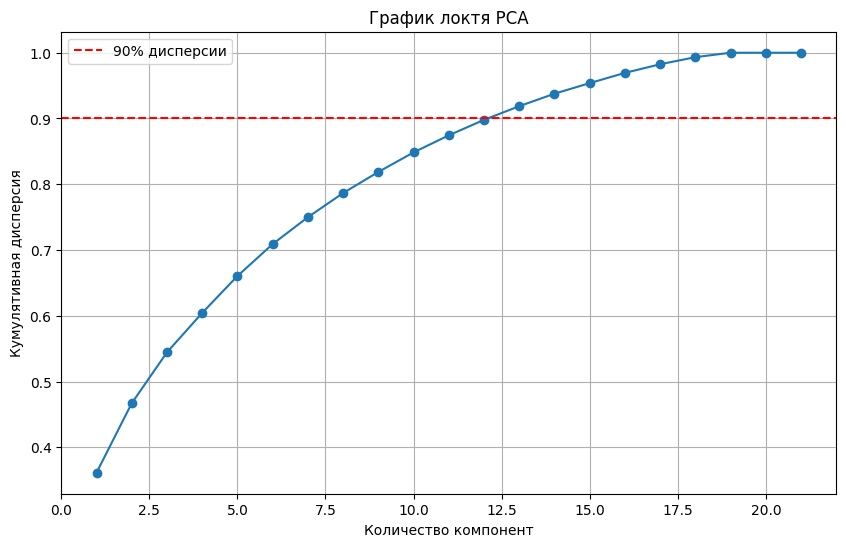

Количество компонент для 90% дисперсии: 13

Первые 5 строк PCA датасета:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  4.602233  0.283202 -1.796597 -0.767436  1.201800  0.360642  1.145177   
1 -2.611680 -0.414308  1.156290  1.334561 -0.454753 -0.379694  1.050962   
2  2.056089 -0.430031  0.103489  0.519517  1.024382 -1.161931  0.527796   
3 -2.596267 -1.224284 -0.031001  0.775521  0.746989 -1.016756 -1.079316   
4 -0.258118  0.762019  0.811709 -0.205797 -0.905700  1.454470 -1.660261   

        PC8       PC9      PC10      PC11      PC12      PC13  
0  1.381563  0.598394 -0.428161  0.759545 -2.155020  0.003104  
1  0.138410 -0.162932  0.079459  0.473791 -0.468098 -0.002620  
2 -0.771830 -0.058882 -0.915369 -0.972173  0.738211  0.623070  
3 -0.718658  0.048113 -0.147727  0.026817 -0.001621  0.074704  
4 -0.294770  1.083117 -1.003764  0.737688  0.053943  0.165109  


In [29]:
pca = PCA()
pca_result = pca.fit_transform(scaled_df)


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% дисперсии')
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная дисперсия')
plt.title('График локтя PCA')
plt.legend()
plt.grid(True)
plt.show()


n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.9) + 1
print(f"Количество компонент для 90% дисперсии: {n_components}")

pca_final = PCA(n_components=n_components)
pca_df = pca_final.fit_transform(scaled_df)

pca_columns = [f'PC{i+1}' for i in range(n_components)]
pca_df = pd.DataFrame(pca_df, columns=pca_columns)
print("\nПервые 5 строк PCA датасета:")
print(pca_df.head())

## 8. Кластеризация K-Means

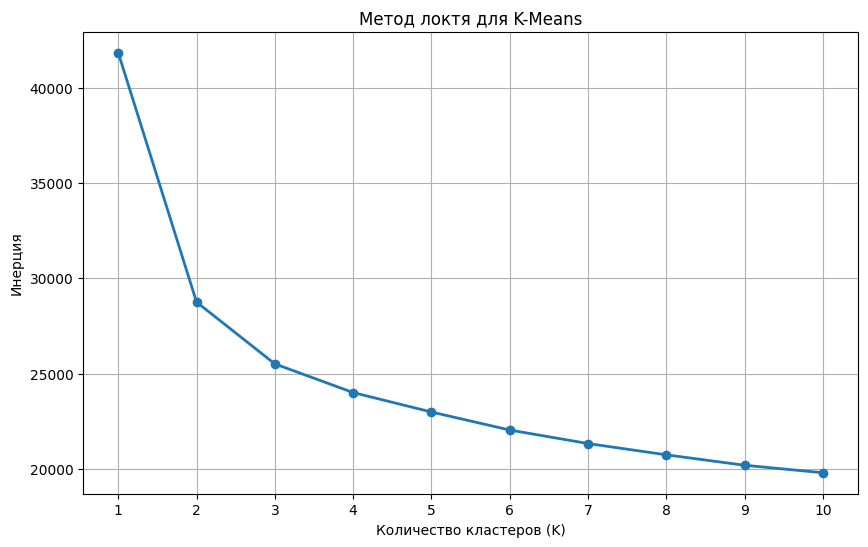

Оптимальное количество кластеров: 3
Распределение клиентов по кластерам:
Кластер 0: 589 клиентов (26.7%)
Кластер 1: 1043 клиентов (47.3%)
Кластер 2: 573 клиентов (26.0%)

Общее количество клиентов: 2205


In [32]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linewidth=2)
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Инерция')
plt.title('Метод локтя для K-Means')
plt.grid(True)
plt.xticks(k_range)
plt.show()

optimal_k = 3
print(f"Оптимальное количество кластеров: {optimal_k}")

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(pca_df)


df_clean['Cluster'] = clusters

print("Распределение клиентов по кластерам:")
cluster_counts = df_clean['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"Кластер {cluster}: {count} клиентов ({count/len(df_clean)*100:.1f}%)")
print(f"\nОбщее количество клиентов: {len(df_clean)}")

## 9. 3D визуализация кластеров

Объясненная дисперсия первыми 3 компонентами: 0.5445 (54.45%)

Дисперсия каждой из первых 3 компонент:
PC1: 0.3615 (36.15%)
PC2: 0.1056 (10.56%)
PC3: 0.0774 (7.74%)


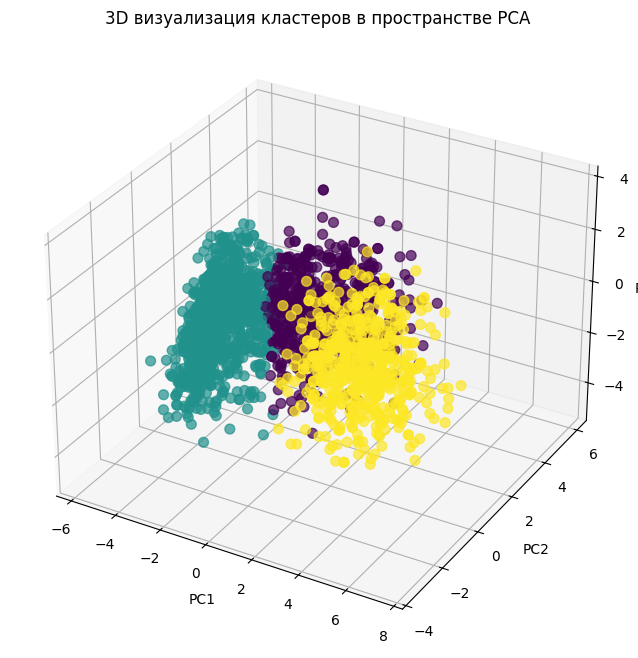

In [39]:
pca_3d = PCA(n_components=3)
pca_3d_result = pca_3d.fit_transform(scaled_df)

explained_variance_3d = np.sum(pca_3d.explained_variance_ratio_)
print(f"Объясненная дисперсия первыми 3 компонентами: {explained_variance_3d:.4f} ({explained_variance_3d*100:.2f}%)")

print("\nДисперсия каждой из первых 3 компонент:")
for i, var in enumerate(pca_3d.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(pca_3d_result[:, 0], pca_3d_result[:, 1], pca_3d_result[:, 2], 
                    c=df_clean['Cluster'], cmap='viridis', s=50, alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D визуализация кластеров в пространстве PCA')

plt.show()



## 10. Профилирование кластеров и ключевые инсайты

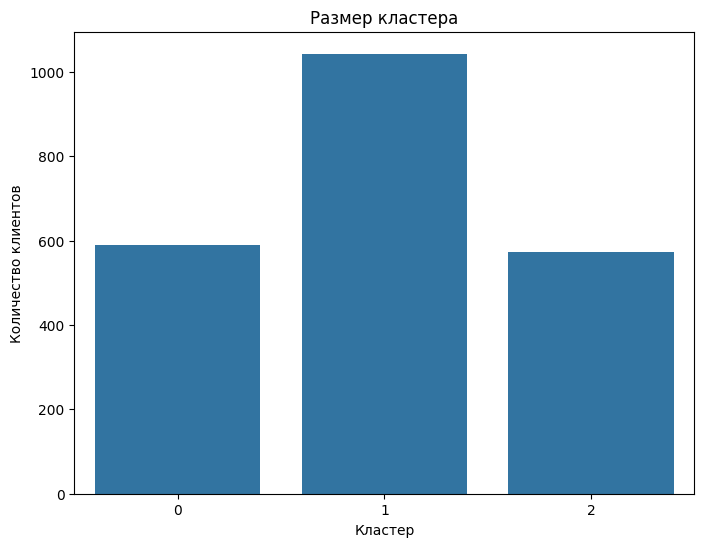

In [43]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='Cluster')
plt.title('Размер кластера')
plt.xlabel('Кластер')
plt.ylabel('Количество клиентов')
plt.show()

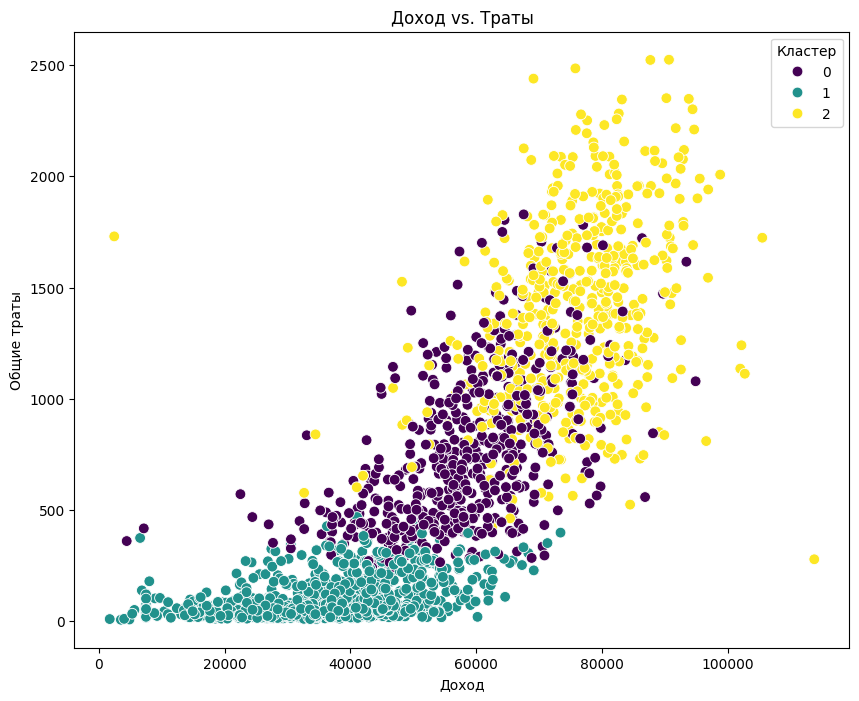

In [44]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_clean, x='Income', y='Total_spent', hue='Cluster', palette='viridis', s=60)
plt.title('Доход vs. Траты')
plt.xlabel('Доход')
plt.ylabel('Общие траты')
plt.legend(title='Кластер')
plt.show()

<Figure size 1200x600 with 0 Axes>

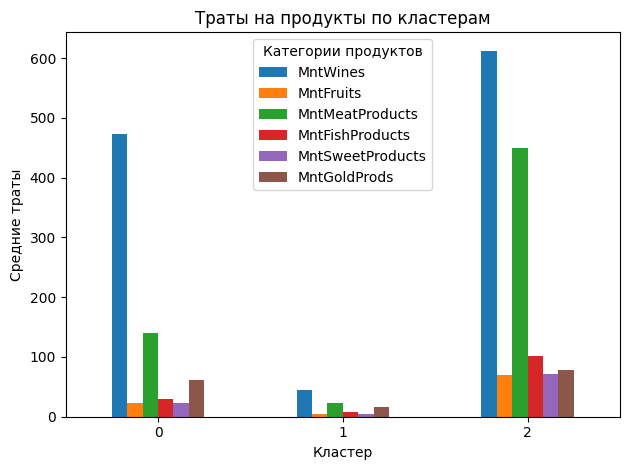

In [45]:
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spending_means = df_clean.groupby('Cluster')[spending_cols].mean()

plt.figure(figsize=(12, 6))
spending_means.plot(kind='bar')
plt.title('Траты на продукты по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Средние траты')
plt.xticks(rotation=0)
plt.legend(title='Категории продуктов')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

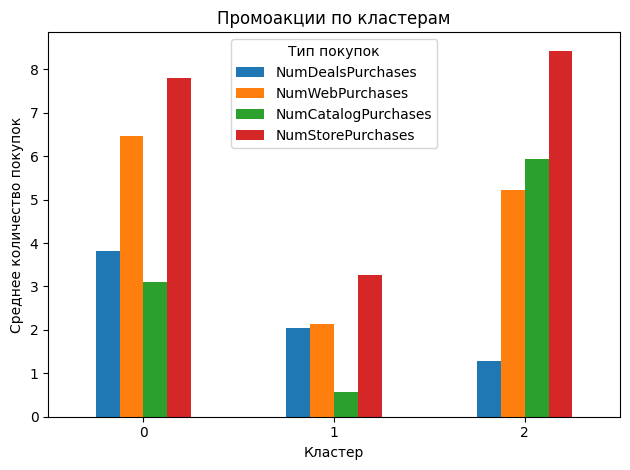

In [46]:
promo_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
promo_means = df_clean.groupby('Cluster')[promo_cols].mean()

plt.figure(figsize=(12, 6))
promo_means.plot(kind='bar')
plt.title('Промоакции по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Среднее количество покупок')
plt.xticks(rotation=0)
plt.legend(title='Тип покупок')
plt.tight_layout()
plt.show()

## 11. Описание групп

In [48]:
cluster_profiles = df_clean.groupby('Cluster').agg({
    'Income': 'mean',
    'Total_spent': 'mean', 
    'Age': 'mean',
    'Children': 'mean',
    'Family_size': 'mean',
    'MntWines': 'mean',
    'MntMeatProducts': 'mean',
    'NumDealsPurchases': 'mean',
    'NumWebPurchases': 'mean'
}).round(1)

for cluster in range(3):
    data = cluster_profiles.loc[cluster]
    print(f"\nКЛАСТЕР {cluster}:")
    print(f" Доход: {data['Income']:.0f}")
    print(f" Общие траты: {data['Total_spent']:.0f}")
    print(f" Возраст: {data['Age']:.1f} лет")
    print(f" Дети: {data['Children']:.1f}")
    print(f" Размер семьи: {data['Family_size']:.1f}")
    print(f" Траты на вино: {data['MntWines']:.0f}")
    print(f" Траты на мясо: {data['MntMeatProducts']:.0f}")
    print(f" Покупки по акциям: {data['NumDealsPurchases']:.1f}")


КЛАСТЕР 0:
 Доход: 58200
 Общие траты: 749
 Возраст: 55.8 лет
 Дети: 1.2
 Размер семьи: 2.9
 Траты на вино: 472
 Траты на мясо: 140
 Покупки по акциям: 3.8

КЛАСТЕР 1:
 Доход: 34806
 Общие траты: 101
 Возраст: 49.6 лет
 Дети: 1.2
 Размер семьи: 2.9
 Траты на вино: 44
 Траты на мясо: 23
 Покупки по акциям: 2.0

КЛАСТЕР 2:
 Доход: 75469
 Общие траты: 1381
 Возраст: 52.8 лет
 Дети: 0.2
 Размер семьи: 1.8
 Траты на вино: 612
 Траты на мясо: 449
 Покупки по акциям: 1.3


## 12. Сравнительный анализ

         Children  Teenhome  Family_size   Age   Income  Total_spent
Cluster                                                             
0             1.2       0.9          2.9  55.8  58200.3        749.3
1             1.2       0.5          2.9  49.6  34806.3        100.8
2             0.2       0.2          1.8  52.8  75469.1       1381.4


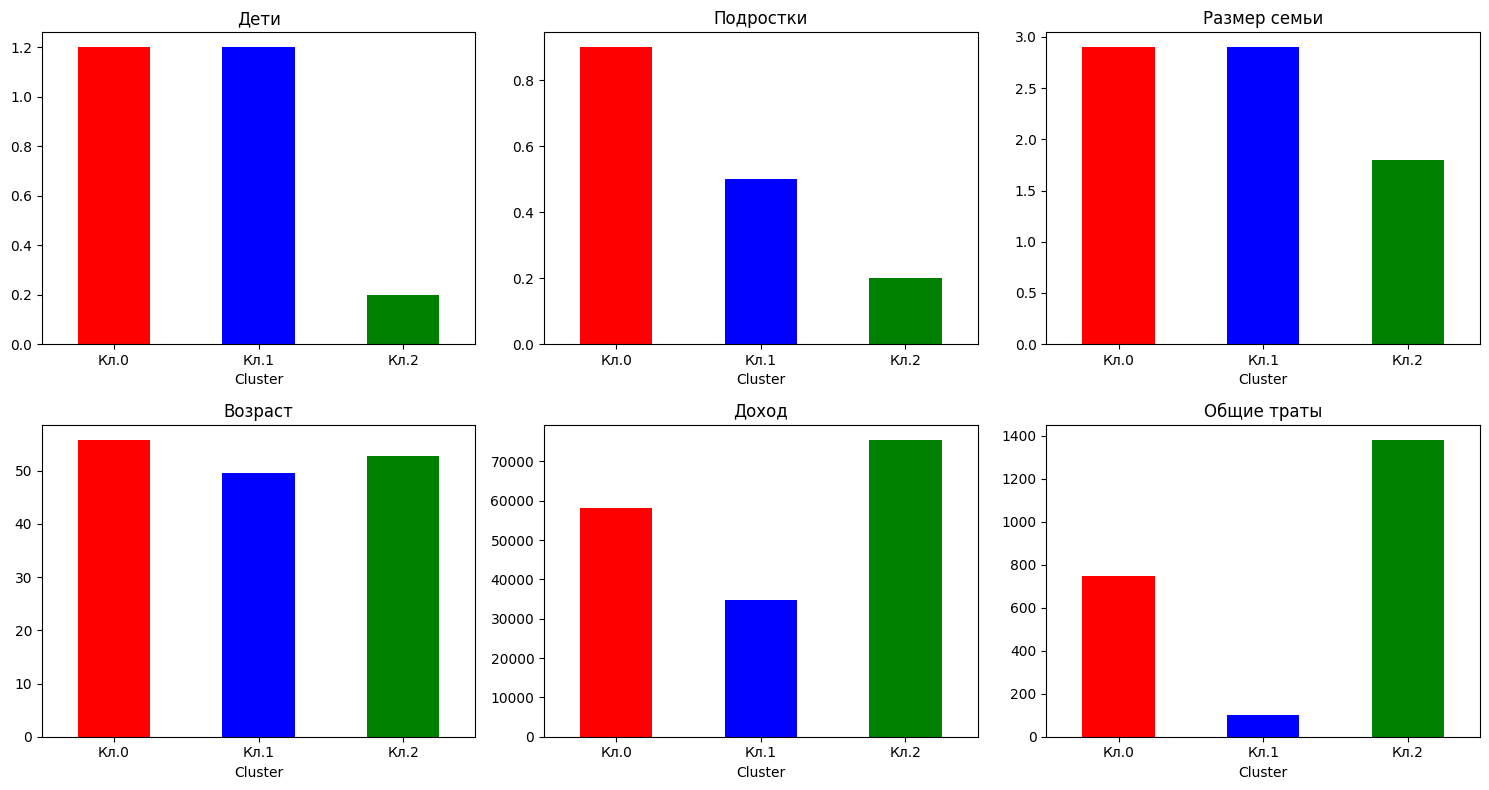

In [47]:
comparison_data = df_clean.groupby('Cluster').agg({
    'Children': 'mean',
    'Teenhome': 'mean',
    'Family_size': 'mean',
    'Age': 'mean',
    'Income': 'mean',
    'Total_spent': 'mean'
}).round(1)

print(comparison_data)

# Простой визуальный анализ
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

metrics = ['Children', 'Teenhome', 'Family_size', 'Age', 'Income', 'Total_spent']
titles = ['Дети', 'Подростки', 'Размер семьи', 'Возраст', 'Доход', 'Общие траты']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    row, col = i // 3, i % 3
    comparison_data[metric].plot(kind='bar', ax=axes[row, col], color=['red', 'blue', 'green'])
    axes[row, col].set_title(title)
    axes[row, col].set_xticklabels(['Кл.0', 'Кл.1', 'Кл.2'], rotation=0)

plt.tight_layout()
plt.show()